In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk

from radiomics import featureextractor

### Define dataset path and class labels

In [3]:
data_path = r"C:\Users\HP PC\Downloads\COVID_IEEE"
classes = ["covid", "normal", "virus"]

### Define improved preprocessing function

This function performs:

* central chest crop
* CLAHE enhancement
* resizing to a fixed size

In [4]:
def preprocess_and_crop(img, output_size=(256, 256)):
    """
    Preprocess chest X-ray image by:
    1. Cropping the central thoracic/chest region
    2. Applying CLAHE for contrast enhancement
    3. Resizing to a fixed output size
    """
    h, w = img.shape

    # Central chest crop
    y1 = int(0.10 * h)
    y2 = int(0.90 * h)
    x1 = int(0.15 * w)
    x2 = int(0.85 * w)

    img = img[y1:y2, x1:x2]

    # CLAHE enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # Resize to standard size
    img = cv2.resize(img, output_size)

    return img

### Define ROI mask function

Since the image is already cropped to the chest region, we can use a full mask of ones on the cropped image.

In [5]:
def create_roi_mask(img):
    """
    Create a full ROI mask for the cropped chest image.
    """
    return np.ones(img.shape, dtype=np.uint8)

### Visualize a few processed images before extraction

This step is important to confirm that the crop is actually focusing on the chest region.

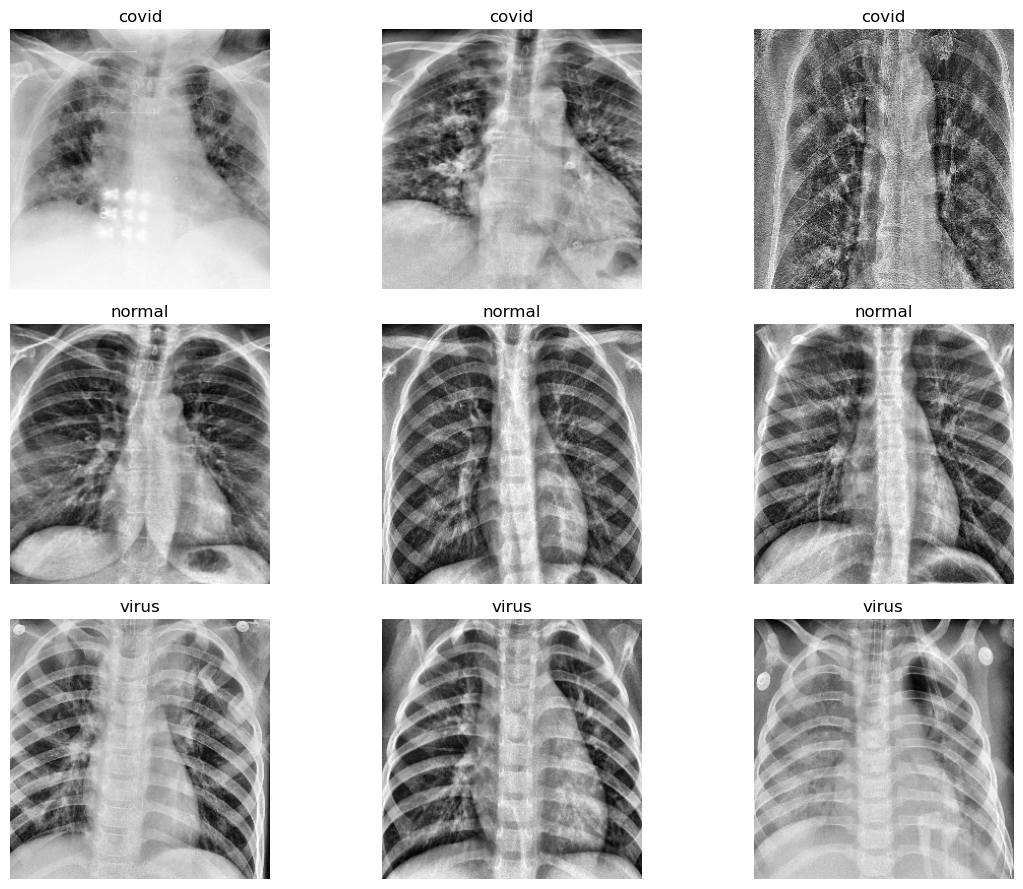

In [7]:
import os
import cv2
import matplotlib.pyplot as plt

data_path = r"C:\Users\HP PC\Downloads\COVID_IEEE"
classes = ["covid", "normal", "virus"]

plot_idx = 1  # ✅ FIX: initialize counter

plt.figure(figsize=(12, 9))

for cls in classes:
    class_dir = os.path.join(data_path, cls)
    files = os.listdir(class_dir)[:3]

    for fname in files:
        fpath = os.path.join(class_dir, fname)
        img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img_processed = preprocess_and_crop(img)

        plt.subplot(len(classes), 3, plot_idx)
        plt.imshow(img_processed, cmap="gray")
        plt.title(cls)
        plt.axis("off")

        plot_idx += 1  # increment

plt.tight_layout()
plt.show()

### Extra improvement (optional but useful)

If you want safer plotting (in case some images fail):

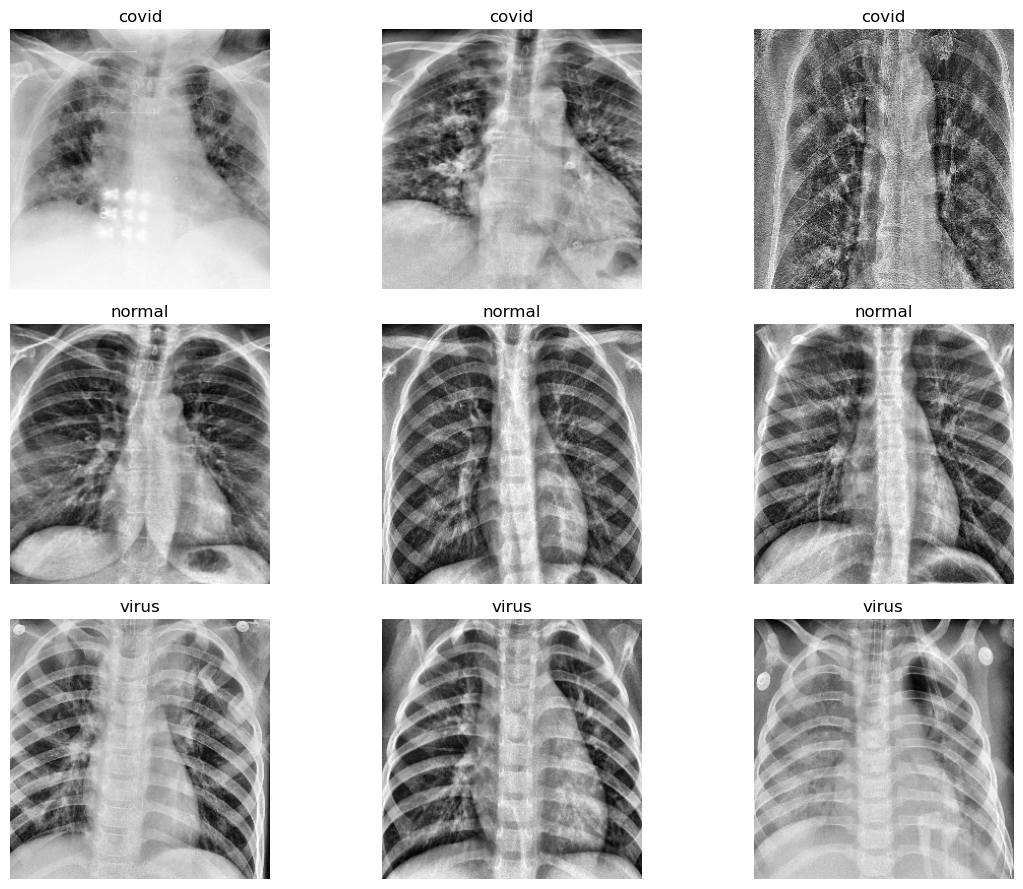

In [8]:
max_images_per_class = 3
plot_idx = 1

plt.figure(figsize=(12, 9))

for cls in classes:
    class_dir = os.path.join(data_path, cls)
    files = os.listdir(class_dir)

    count = 0
    for fname in files:
        if count >= max_images_per_class:
            break

        fpath = os.path.join(class_dir, fname)
        img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img_processed = preprocess_and_crop(img)

        plt.subplot(len(classes), max_images_per_class, plot_idx)
        plt.imshow(img_processed, cmap="gray")
        plt.title(cls)
        plt.axis("off")

        plot_idx += 1
        count += 1

plt.tight_layout()
plt.show()

### Configure PyRadiomics extractor

This setup enables both:

* original image features
* wavelet-based features

In [9]:
params = {
    "binWidth": 25,
    "resampledPixelSpacing": None,
    "interpolator": "sitkBSpline",
    "verbose": True
}

extractor = featureextractor.RadiomicsFeatureExtractor(**params)

extractor.enableImageTypeByName("Original")
extractor.enableImageTypeByName("Wavelet")
extractor.enableAllFeatures()

### Extract improved radiomics features

This cell loops through all images, applies the improved preprocessing, creates a mask, and extracts radiomics features.

In [10]:
rows = []

for label in classes:
    class_dir = os.path.join(data_path, label)

    for fname in os.listdir(class_dir):
        fpath = os.path.join(class_dir, fname)

        img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Skipping unreadable image: {fpath}")
            continue

        # Improved preprocessing
        img_processed = preprocess_and_crop(img, output_size=(256, 256))
        mask = create_roi_mask(img_processed)

        # Convert to SimpleITK
        img_sitk = sitk.GetImageFromArray(img_processed)
        mask_sitk = sitk.GetImageFromArray(mask)

        try:
            features = extractor.execute(img_sitk, mask_sitk)

            clean_features = {}
            for k, v in features.items():
                if not k.startswith("diagnostics"):
                    clean_features[k] = v

            clean_features["label"] = label
            clean_features["filename"] = fname

            rows.append(clean_features)

        except Exception as e:
            print(f"Feature extraction failed for {fpath}: {e}")

df_improved = pd.DataFrame(rows)

print("Feature extraction completed.")
print("Extracted feature table shape:", df_improved.shape)
df_improved.head()

Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 nee

Feature extraction completed.
Extracted feature table shape: (1823, 476)


,original_shape2D_Elongation,original_shape2D_MajorAxisLength,original_shape2D_MaximumDiameter,original_shape2D_MeshSurface,original_shape2D_MinorAxisLength,original_shape2D_Perimeter,original_shape2D_PerimeterSurfaceRatio,original_shape2D_PixelSurface,original_shape2D_Sphericity,original_firstorder_10Percentile,...,wavelet-LL_glszm_ZoneEntropy,wavelet-LL_glszm_ZonePercentage,wavelet-LL_glszm_ZoneVariance,wavelet-LL_ngtdm_Busyness,wavelet-LL_ngtdm_Coarseness,wavelet-LL_ngtdm_Complexity,wavelet-LL_ngtdm_Contrast,wavelet-LL_ngtdm_Strength,label,filename
0,1.0,295.601083,361.33225707096784,65535.5,295.601083,1022.8284271247462,0.015607242290434134,65536.0,0.887239,102.0,...,7.9350331308453805,0.0244598388671875,82864.40123847636,2.9788427826694064,0.0009746062994529394,42.505326628025976,0.017911001893627414,0.18228862266986887,covid,01E392EE-69F9-4E33-BFCE-E5C968654078.jpeg
1,1.0,295.601083,361.33225707096784,65535.5,295.601083,1022.8284271247462,0.015607242290434134,65536.0,0.887239,84.0,...,7.93141320385495,0.041473388671875,30129.543045816157,9.75518992591981,0.0005191618961890481,36.10478914524177,0.020078596853347036,0.058740356283453136,covid,03BF7561-A9BA-4C3C-B8A0-D3E585F73F3C.jpeg
2,1.0,295.601083,361.33225707096784,65535.5,295.601083,1022.8284271247462,0.015607242290434134,65536.0,0.887239,61.0,...,6.936232737013603,0.1713714599609375,239.68420114958883,21.203498278905283,0.00031125631893894247,74.80243825577179,0.033879663199899414,0.03558069803388324,covid,1-s2.0-S0140673620303706-fx1_lrg.jpg
3,1.0,295.601083,361.33225707096784,65535.5,295.601083,1022.8284271247462,0.015607242290434134,65536.0,0.887239,64.0,...,7.751487318754953,0.03265380859375,70911.15884880775,7.018293028363807,0.0005611413197171827,39.75952476647099,0.018736950320596836,0.07928408360807342,covid,1-s2.0-S0929664620300449-gr2_lrg-a.jpg
4,1.0,295.601083,361.33225707096784,65535.5,295.601083,1022.8284271247462,0.015607242290434134,65536.0,0.887239,64.0,...,7.4955947883893135,0.0747222900390625,17592.738633034714,8.819679259291755,0.0005206832235750624,50.520897150503295,0.03284499940595048,0.06845017640462601,covid,1-s2.0-S0929664620300449-gr2_lrg-b.jpg


### Save extracted features

In [11]:
output_csv = "radiomics_features_central_crop.csv"
df_improved.to_csv(output_csv, index=False)

print(f"Improved radiomics features saved to: {output_csv}")

Improved radiomics features saved to: radiomics_features_central_crop.csv


In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier


# =========================================================
# 1. LOAD FEATURES
# =========================================================
# Change this if needed
df = pd.read_csv("radiomics_features_central_crop.csv")

print("Dataset shape:", df.shape)
print(df.head())


# =========================================================
# 2. DEFINE X AND y
# =========================================================
X = df.drop(columns=["label", "filename"])
y = df["label"]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())


# =========================================================
# 3. ENCODE LABELS
# =========================================================
le = LabelEncoder()
y_enc = le.fit_transform(y)

print("\nEncoded classes:", le.classes_)


# =========================================================
# 4. TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


# =========================================================
# 5. HELPER: XGBoost model
# =========================================================
def build_xgb():
    return XGBClassifier(
        objective="multi:softprob",
        num_class=len(le.classes_),
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )


# =========================================================
# 6. DEFINE PIPELINES
# =========================================================
pipelines = {
    "XGBoost": Pipeline([
        ("var_thresh", VarianceThreshold(0.0)),
        ("clf", build_xgb())
    ]),

    "PCA + XGBoost": Pipeline([
        ("var_thresh", VarianceThreshold(0.0)),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("clf", build_xgb())
    ]),

    "Feature Selection + XGBoost": Pipeline([
        ("var_thresh", VarianceThreshold(0.0)),
        ("selector", SelectKBest(score_func=f_classif, k=50)),
        ("clf", build_xgb())
    ])
}


# =========================================================
# 7. TRAIN + EVALUATE ALL PIPELINES
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
trained_models = {}
confusion_matrices = {}

for name, pipeline in pipelines.items():
    print("\n" + "=" * 70)
    print(f"MODEL: {name}")
    print("=" * 70)

    # Cross-validation on training data only
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    # Fit on full training set
    pipeline.fit(X_train, y_train)

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    gap = train_acc - test_acc

    print("CV Scores:", cv_scores)
    print("CV Mean:", cv_scores.mean())
    print("CV Std:", cv_scores.std())
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print("Generalization Gap:", gap)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_test_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_test_pred)
    cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

    print("Confusion Matrix:\n")
    print(cm_df)

    results.append({
        "Model": name,
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Gap": gap
    })

    trained_models[name] = pipeline
    confusion_matrices[name] = cm_df


# =========================================================
# 8. FINAL COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False)

print("\n" + "=" * 70)
print("FINAL COMPARISON TABLE")
print("=" * 70)
print(results_df)


# =========================================================
# 9. OPTIONAL EXTRA DETAILS
# =========================================================
if "PCA + XGBoost" in trained_models:
    pca_model = trained_models["PCA + XGBoost"].named_steps["pca"]
    print("\nPCA DETAILS")
    print("Original features:", X_train.shape[1])
    print("Retained PCA components:", pca_model.n_components_)

if "Feature Selection + XGBoost" in trained_models:
    selector = trained_models["Feature Selection + XGBoost"].named_steps["selector"]
    print("\nFEATURE SELECTION DETAILS")
    print("Original features:", X_train.shape[1])
    print("Selected features:", selector.get_support().sum())

Dataset shape: (1823, 476)
   original_shape2D_Elongation  original_shape2D_MajorAxisLength  \
0                          1.0                        295.601083   
1                          1.0                        295.601083   
2                          1.0                        295.601083   
3                          1.0                        295.601083   
4                          1.0                        295.601083   

   original_shape2D_MaximumDiameter  original_shape2D_MeshSurface  \
0                        361.332257                       65535.5   
1                        361.332257                       65535.5   
2                        361.332257                       65535.5   
3                        361.332257                       65535.5   
4                        361.332257                       65535.5   

   original_shape2D_MinorAxisLength  original_shape2D_Perimeter  \
0                        295.601083                 1022.828427   
1              

## Central Chest ROI → Radiomics → LightGBM

Dataset shape: (1823, 476)
   original_shape2D_Elongation  original_shape2D_MajorAxisLength  \
0                          1.0                        295.601083   
1                          1.0                        295.601083   
2                          1.0                        295.601083   
3                          1.0                        295.601083   
4                          1.0                        295.601083   

   original_shape2D_MaximumDiameter  original_shape2D_MeshSurface  \
0                        361.332257                       65535.5   
1                        361.332257                       65535.5   
2                        361.332257                       65535.5   
3                        361.332257                       65535.5   
4                        361.332257                       65535.5   

   original_shape2D_MinorAxisLength  original_shape2D_Perimeter  \
0                        295.601083                 1022.828427   
1              

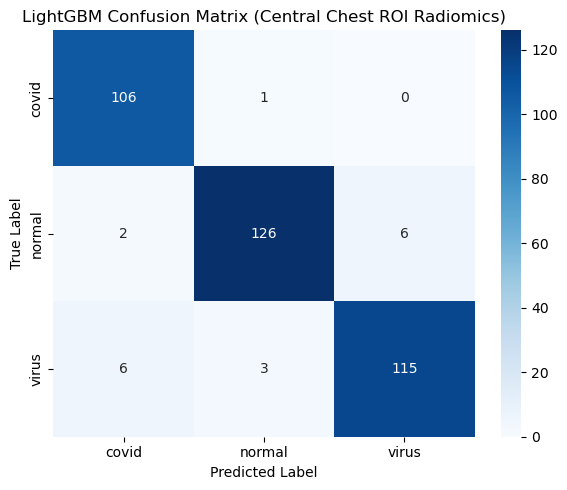

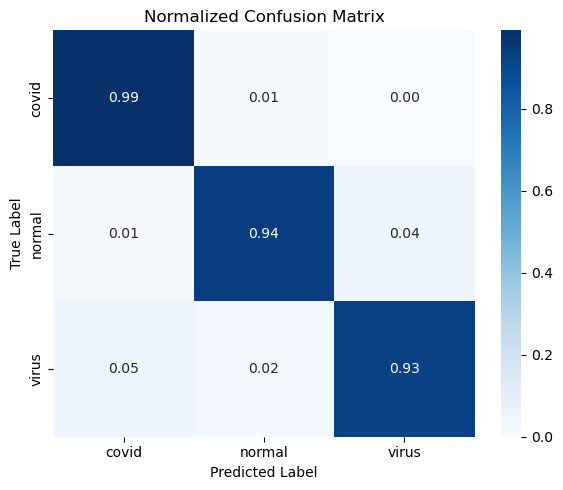


TOP 20 FEATURE IMPORTANCE
                                              feature  importance
293                    wavelet-HH_firstorder_Skewness         279
454                wavelet-LL_glszm_SmallAreaEmphasis         279
288                      wavelet-HH_firstorder_Median         275
217                              wavelet-HL_glcm_Imc1         230
284                    wavelet-HH_firstorder_Kurtosis         224
317                wavelet-HH_glcm_MaximumProbability         209
124                              wavelet-LH_glcm_Imc1         200
312                   wavelet-HH_glcm_InverseVariance         184
347                      wavelet-HH_glrlm_RunVariance         176
218                              wavelet-HL_glcm_Imc2         169
102                      wavelet-LH_firstorder_Median         162
14                       original_firstorder_Skewness         159
223                               wavelet-HL_glcm_MCC         159
453  wavelet-LL_glszm_SizeZoneNonUniformityNormal

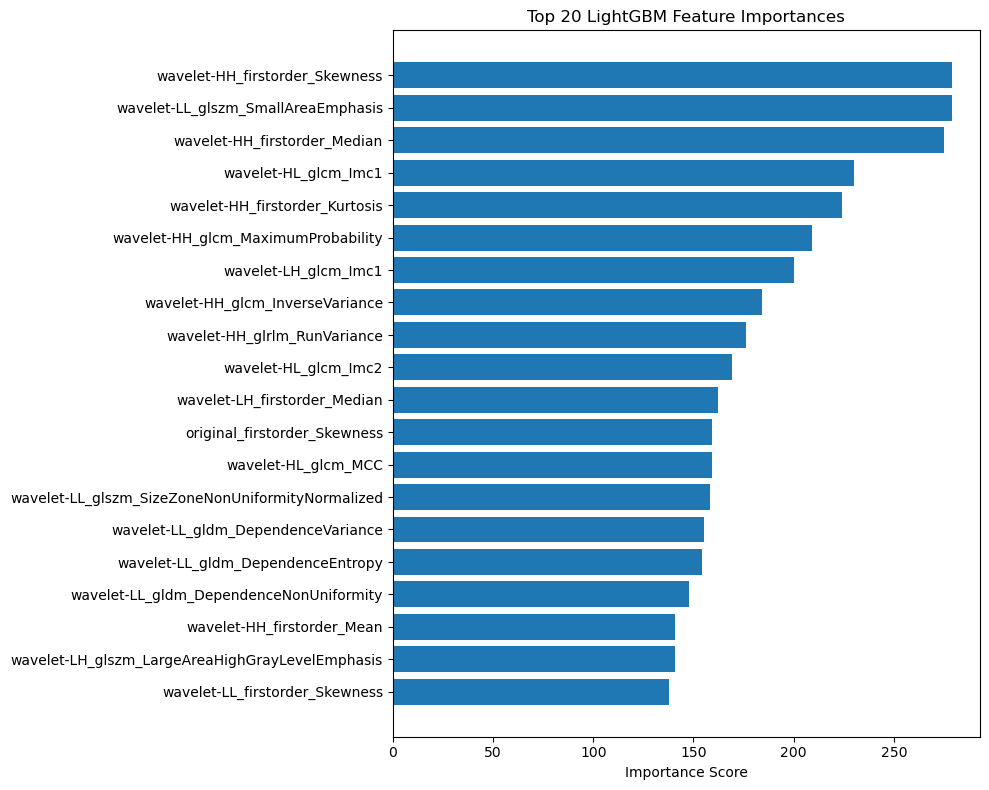


Saved:
- lightgbm_central_crop_model.pkl
- label_encoder_central_crop.pkl
- lightgbm_feature_importance_central_crop.csv


In [14]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from lightgbm import LGBMClassifier


# =========================================================
# 1. LOAD CENTRAL CHEST ROI RADIOMICS FEATURES
# =========================================================
df = pd.read_csv("radiomics_features_central_crop.csv")

print("Dataset shape:", df.shape)
print(df.head())


# =========================================================
# 2. DEFINE FEATURES AND TARGET
# =========================================================
X = df.drop(columns=["label", "filename"])
y = df["label"]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())


# =========================================================
# 3. ENCODE LABELS
# =========================================================
le = LabelEncoder()
y_enc = le.fit_transform(y)

print("\nEncoded classes:", le.classes_)


# =========================================================
# 4. TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


# =========================================================
# 5. BUILD LIGHTGBM PIPELINE
# =========================================================
lgbm_pipeline = Pipeline([
    ("var_thresh", VarianceThreshold(0.0)),
    ("clf", LGBMClassifier(
        objective="multiclass",
        num_class=len(le.classes_),

        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,

        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,

        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])


# =========================================================
# 6. CROSS-VALIDATION ON TRAINING SET
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    lgbm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)
print("CV Scores:", cv_scores)
print("CV Mean:", cv_scores.mean())
print("CV Std:", cv_scores.std())


# =========================================================
# 7. TRAIN FINAL MODEL
# =========================================================
lgbm_pipeline.fit(X_train, y_train)


# =========================================================
# 8. PREDICTIONS
# =========================================================
y_train_pred = lgbm_pipeline.predict(X_train)
y_test_pred = lgbm_pipeline.predict(X_test)


# =========================================================
# 9. TRAINING PERFORMANCE
# =========================================================
print("\n" + "="*60)
print("TRAINING PERFORMANCE")
print("="*60)
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))

print("\nTrain Classification Report:\n")
print(classification_report(y_train, y_train_pred, target_names=le.classes_))


# =========================================================
# 10. TEST PERFORMANCE
# =========================================================
print("\n" + "="*60)
print("TEST PERFORMANCE")
print("="*60)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nTest Classification Report:\n")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))


# =========================================================
# 11. NUMERICAL CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_test, y_test_pred)

cm_df = pd.DataFrame(
    cm,
    index=le.classes_,
    columns=le.classes_
)

print("\n" + "="*60)
print("NUMERICAL CONFUSION MATRIX")
print("="*60)
print(cm_df)


# =========================================================
# 12. HEATMAP CONFUSION MATRIX
# =========================================================
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("LightGBM Confusion Matrix (Central Chest ROI Radiomics)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


# =========================================================
# 13. NORMALIZED HEATMAP (OPTIONAL BUT VERY USEFUL)
# =========================================================
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


# =========================================================
# 14. FEATURE IMPORTANCE
# =========================================================
model = lgbm_pipeline.named_steps["clf"]
var_selector = lgbm_pipeline.named_steps["var_thresh"]

selected_features = X_train.columns[var_selector.get_support()]

importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\n" + "="*60)
print("TOP 20 FEATURE IMPORTANCE")
print("="*60)
print(importance_df.head(20))


# =========================================================
# 15. FEATURE IMPORTANCE PLOT
# =========================================================
top_n = 20

plt.figure(figsize=(10, 8))
plt.barh(
    importance_df["feature"].head(top_n)[::-1],
    importance_df["importance"].head(top_n)[::-1]
)
plt.title("Top 20 LightGBM Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


# =========================================================
# 16. SAVE MODEL + LABEL ENCODER + IMPORTANCE CSV
# =========================================================
joblib.dump(lgbm_pipeline, "lightgbm_central_crop_model.pkl")
joblib.dump(le, "label_encoder_central_crop.pkl")
importance_df.to_csv("lightgbm_feature_importance_central_crop.csv", index=False)

print("\nSaved:")
print("- lightgbm_central_crop_model.pkl")
print("- label_encoder_central_crop.pkl")
print("- lightgbm_feature_importance_central_crop.csv")

In [15]:
joblib.dump(X.columns.tolist(), "feature_columns_central_crop.pkl")
print("Saved feature columns.")

Saved feature columns.


### Save model, label encoder, and feature columns

In [16]:
from pathlib import Path
import joblib

# Assumes these already exist from your training notebook:
# lgbm_pipeline
# le
# X

app_dir = Path(r"Chestproject_App")
app_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(lgbm_pipeline, app_dir / "lightgbm_central_crop_model.pkl")
joblib.dump(le, app_dir / "label_encoder_central_crop.pkl")
joblib.dump(X.columns.tolist(), app_dir / "feature_columns_central_crop.pkl")

print("Saved files:")
print(app_dir / "lightgbm_central_crop_model.pkl")
print(app_dir / "label_encoder_central_crop.pkl")
print(app_dir / "feature_columns_central_crop.pkl")

Saved files:
Chestproject_App\lightgbm_central_crop_model.pkl
Chestproject_App\label_encoder_central_crop.pkl
Chestproject_App\feature_columns_central_crop.pkl


### Pathway to strealit

In [ ]:
cd "Data_Science\Medical Tasks\Chestproject_App"
python -m streamlit run app.py

###  Pathway FastAPI  (Back end)

In [ ]:
cd "Data_Science\Medical Tasks\Chestproject_App"
uvicorn main:app --reload